## 1. Importing libraries

In [7]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind


## 2. Load each country's cleaned CSV and concatenate into a single DataFrame

In [8]:
# List of countries with their file paths
countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']

# Create an empty list to store each DataFrame
dataframes = []

# Loop through each country and load their CSV file
for country in countries:
    file_path = f'../data/{country}_clean.csv'  # Adjust path if needed
    
    try:
        # Load the CSV file
        df = pd.read_csv(file_path)
        
        # Add to our list
        dataframes.append(df)
        
        # Print confirmation
        print(f"✓ Loaded {country}: {len(df)} rows, {len(df.columns)} columns")
        
    except FileNotFoundError:
        print(f"✗ File not found: {file_path}")
    except Exception as e:
        print(f"✗ Error loading {country}: {e}")

# Concatenate all DataFrames into a single DataFrame
if dataframes:
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    print("\n" + "="*50)
    print("CONCATENATION COMPLETE")
    print("="*50)
    print(f"Total rows in combined DataFrame: {len(combined_df):,}")
    print(f"Total columns: {len(combined_df.columns)}")
    print(f"Countries included: {combined_df['Country'].unique().tolist()}")
    print(f"Date range: {combined_df['Date'].min()} to {combined_df['Date'].max()}")
    
    # Display first few rows to verify
    print("\nFirst 5 rows of combined DataFrame:")
    print(combined_df.head())
    
    # Display basic info
    print("\nDataFrame info:")
    print(combined_df.info())
    
else:
    print("No data was loaded. Please check file paths and try again.")
    combined_df = None

✓ Loaded ethiopia: 4108 rows, 16 columns
✓ Loaded kenya: 4108 rows, 16 columns
✓ Loaded nigeria: 4108 rows, 16 columns
✓ Loaded sudan: 4108 rows, 16 columns
✓ Loaded tanzania: 4108 rows, 16 columns

CONCATENATION COMPLETE
Total rows in combined DataFrame: 20,540
Total columns: 16
Countries included: ['Ethiopia', 'Kenya', 'Nigeria', 'Sudan', 'Tanzania']
Date range: 2015-01-01 to 2026-03-31

First 5 rows of combined DataFrame:
   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  11.73    22.75     3.44      19.31          0.0  41.79  2.73   
1  2015    2  12.30    24.01     4.09      19.92          0.0  33.29  2.39   
2  2015    3  12.49    24.17     3.97      20.20          0.0  33.83  1.77   
3  2015    4  14.08    23.78     6.90      16.88          0.0  38.84  0.87   
4  2015    5  14.06    23.15     7.32      15.83          0.0  47.07  1.34   

   WS2M_MAX     PS  QV2M   Country        Date  Month  is_outlier  
0      5.07  77.13  4.00  Ethiopia

## 3. Temperature Trend Comparison

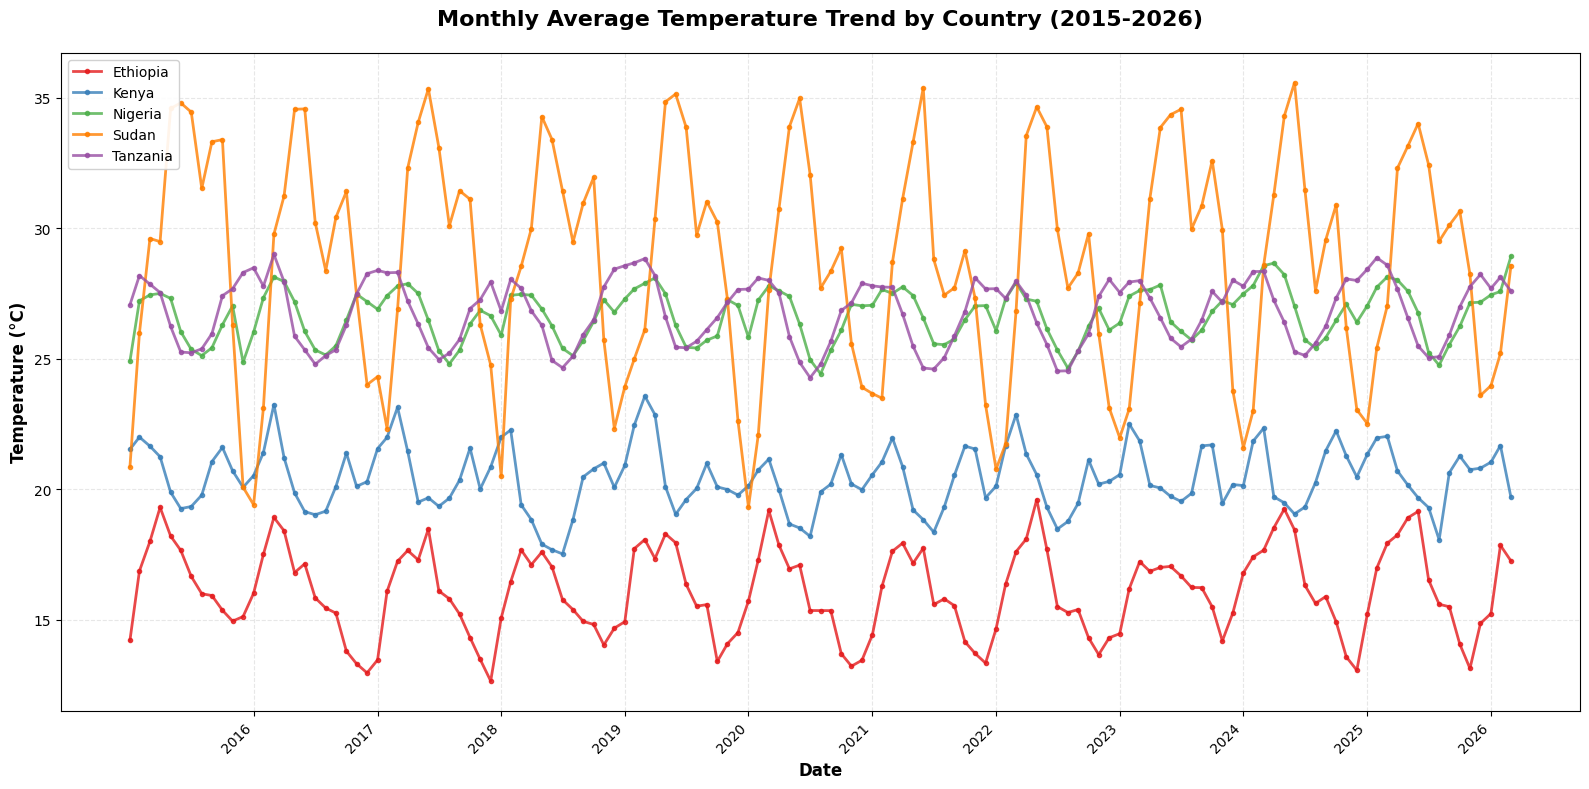

In [9]:
# Ensure Date is datetime
combined_df['Date'] = pd.to_datetime(combined_df['Date'])

# Create monthly average temperature for each country
monthly_temp_by_country = combined_df.groupby(['Country', pd.Grouper(key='Date', freq='ME')])['T2M'].mean().reset_index()

# Create the line chart
plt.figure(figsize=(16, 8))

# Define color palette for 5 countries
colors = {
    'Ethiopia': '#e41a1c',    # Red
    'Kenya': '#377eb8',        # Blue
    'Nigeria': '#4daf4a',      # Green
    'Sudan': '#ff7f00',        # Orange
    'Tanzania': '#984ea3'      # Purple
}

# Plot each country
for country in monthly_temp_by_country['Country'].unique():
    country_data = monthly_temp_by_country[monthly_temp_by_country['Country'] == country]
    plt.plot(country_data['Date'], country_data['T2M'], 
             label=country, linewidth=2, marker='o', markersize=3,
             color=colors[country], alpha=0.8)

# Customize the chart
plt.title('Monthly Average Temperature Trend by Country (2015-2026)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='semibold')
plt.ylabel('Temperature (°C)', fontsize=12, fontweight='semibold')
plt.legend(loc='upper left', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')

# Improve x-axis spacing - show every 12 months
ax = plt.gca()
years = pd.date_range(start='2016-01-01', end='2026-3-31', freq='12ME')
ax.set_xticks(years)
ax.set_xticklabels([yr.strftime('%Y') for yr in years])

plt.tight_layout()
plt.show()

### Trend and patterns
Across the five countries a few clear patterns emerge:

**a. Strong seasonality everywhere**

All countries show clear cyclical temperature patterns (peaks and dips each year).

This reflects seasonal climate systems (wet/dry seasons rather than four seasons like temperate regions).

**b. Sudan is consistently the hottest—and most volatile**

Monthly averages often reach 33–36°C peaks, far above others.

Also shows the largest swings (from ~20°C to mid-30s).

This indicates high temperature variability, which is a stress multiplier.

**c. Ethiopia is coolest but still warming**

Range roughly 13–19°C, much lower than peers due to elevation.

However, there’s a slight upward drift in peaks over time.

**d. Kenya sits in a narrow, stable band**

Roughly 18–23°C, with relatively low variability.

Suggests climate buffering, likely due to geography (highlands + coast influence).

**e. Nigeria & Tanzania show moderate warming and consistency**

Both hover around 25–29°C.

Slight upward shift in later years (especially post-2022), hinting at gradual warming trend.

### Key Comparative Insight 

**Heat intensity (absolute exposure):**

Highest: Sudan

Moderate: Nigeria, Tanzania

Lower: Kenya

Lowest: Ethiopia

**Temperature variability (climate stress):**

Highest: Sudan

Moderate: Ethiopia

Lower: Kenya, Tanzania, Nigeria

> *So Sudan is dealing with both high heat and high volatility, which is a red flag for vulnerability.*

### Summary Table: Temperature Statistics by Country

In [10]:
# Create summary statistics table
temp_summary = combined_df.groupby('Country')['T2M'].agg([
    ('Mean (°C)', 'mean'),
    ('Median (°C)', 'median'),
    ('Std Dev (°C)', 'std'),
    ('Min (°C)', 'min'),
    ('Max (°C)', 'max')
]).round(2)

# Sort by mean temperature (optional)
temp_summary = temp_summary.sort_values('Mean (°C)', ascending=False)

print("="*70)
print("TEMPERATURE STATISTICS BY COUNTRY")
print("="*70)
print(temp_summary)

# Add a ranking column
temp_summary['Rank (Warmest to Coolest)'] = temp_summary['Mean (°C)'].rank(ascending=False).astype(int)

print("\n" + "="*70)
print("TEMPERATURE RANKING (Warmest to Coolest)")
print("="*70)
print(temp_summary[['Mean (°C)', 'Rank (Warmest to Coolest)']])

TEMPERATURE STATISTICS BY COUNTRY
          Mean (°C)  Median (°C)  Std Dev (°C)  Min (°C)  Max (°C)
Country                                                           
Sudan         28.76        29.16          4.68     13.18     37.99
Tanzania      26.80        26.99          1.33     22.68     29.97
Nigeria       26.66        26.82          1.12     21.12     29.29
Kenya         20.43        20.36          1.44     15.26     25.40
Ethiopia      16.07        16.04          1.90     10.03     21.53

TEMPERATURE RANKING (Warmest to Coolest)
          Mean (°C)  Rank (Warmest to Coolest)
Country                                       
Sudan         28.76                          1
Tanzania      26.80                          2
Nigeria       26.66                          3
Kenya         20.43                          4
Ethiopia      16.07                          5


### Additional Insight: Enhanced Visualization with Subplots


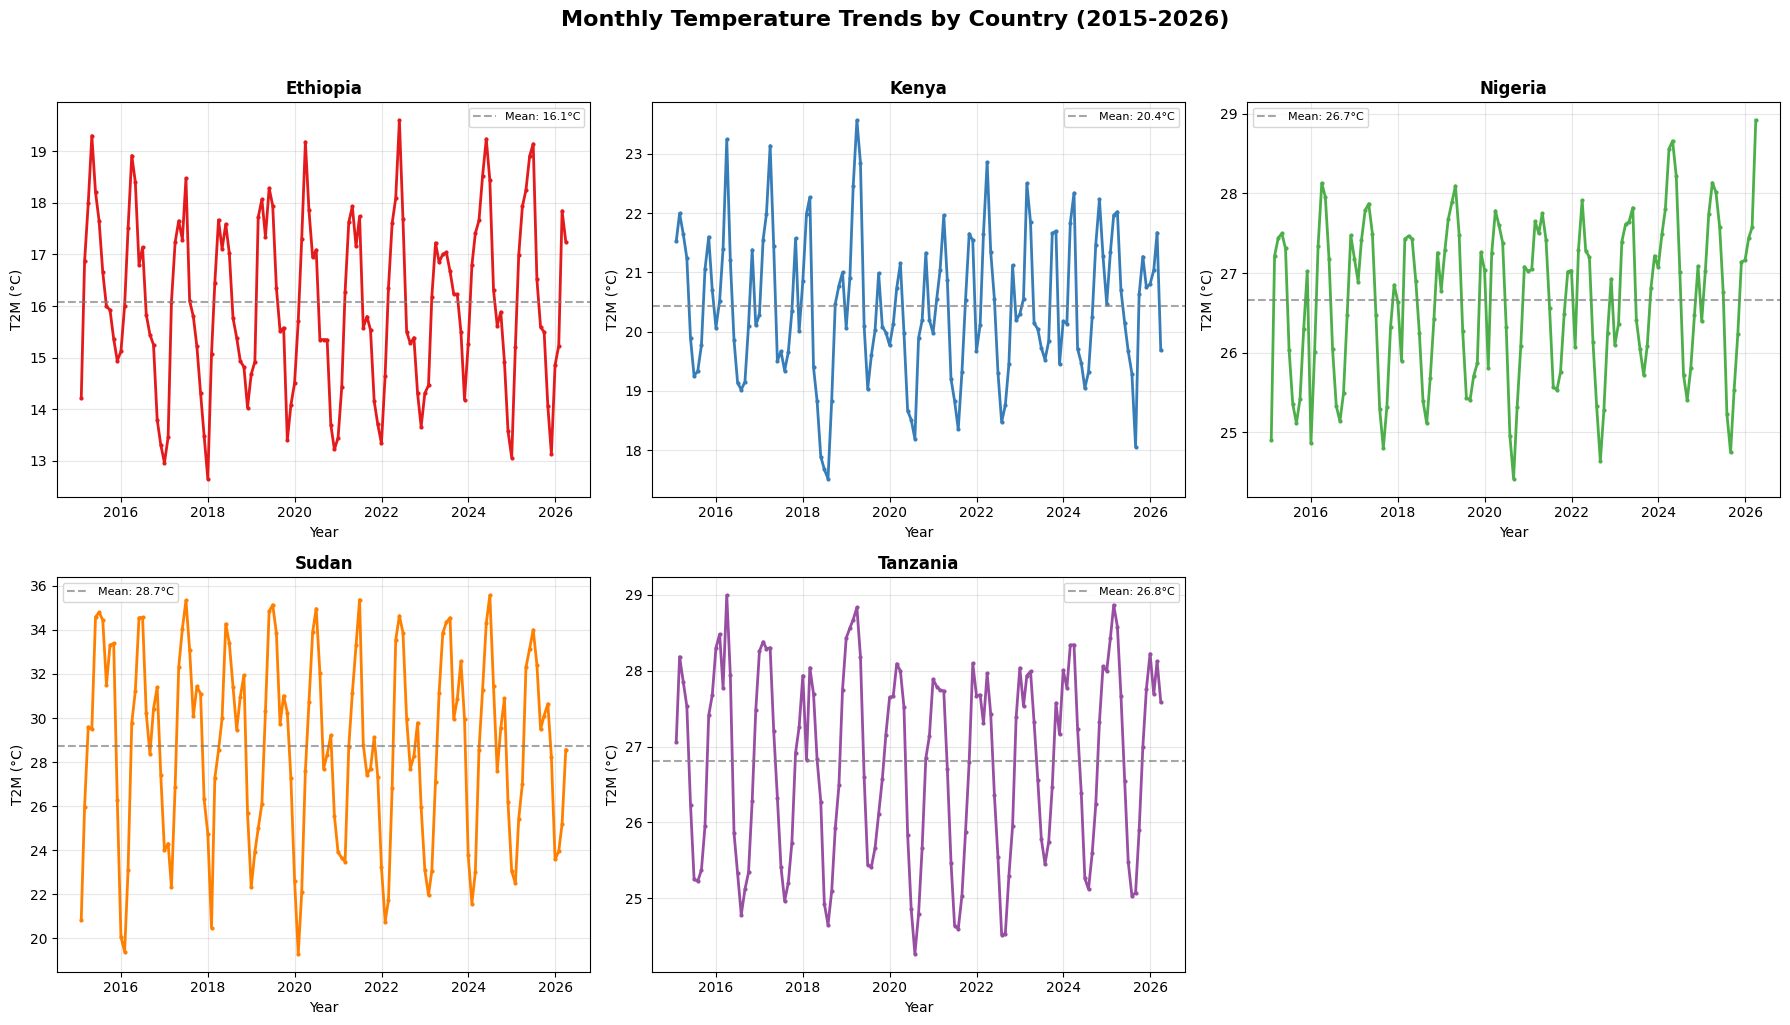

In [11]:
# Create two views: single chart + individual subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot individual country trends in subplots
for idx, country in enumerate(monthly_temp_by_country['Country'].unique()):
    country_data = monthly_temp_by_country[monthly_temp_by_country['Country'] == country]
    
    axes[idx].plot(country_data['Date'], country_data['T2M'], 
                   color=colors[country], linewidth=2, marker='o', markersize=2)
    axes[idx].set_title(f'{country}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Year')
    axes[idx].set_ylabel('T2M (°C)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=country_data['T2M'].mean(), color='gray', linestyle='--', 
                      alpha=0.7, label=f'Mean: {country_data["T2M"].mean():.1f}°C')
    axes[idx].legend(fontsize=8)

# Remove the empty subplot (6th one if 5 countries)
if len(monthly_temp_by_country['Country'].unique()) < 6:
    fig.delaxes(axes[5])

plt.suptitle('Monthly Temperature Trends by Country (2015-2026)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Additional insight: Anomaly calculation

In [36]:
# Calculate annual mean temperature
annual_temp = combined_df.groupby("YEAR")["T2M"].mean().reset_index()

# Choose baseline period (first 5 years)
baseline = annual_temp[annual_temp["YEAR"].between(2015, 2020)]["T2M"].mean()

# Calculate anomalies
annual_temp["T2M_Anomaly"] = annual_temp["T2M"] - baseline

annual_temp

,YEAR,T2M,T2M_Anomaly
0,2015,23.948307,0.231059
1,2016,23.708459,-0.008789
2,2017,23.832521,0.115273
3,2018,23.491058,-0.226190
4,2019,23.984756,0.267508
5,2020,23.338388,-0.378860
6,2021,23.522027,-0.195221
7,2022,23.451797,-0.265451
8,2023,23.982466,0.265218
9,2024,23.935585,0.218337


C:\Users\hp\AppData\Local\Temp\ipykernel_9516\925151238.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  annual_temp = annual_temp.groupby("Country").apply(calculate_anomaly_professional).reset_index(drop=True)


PROFESSIONAL ANOMALY VERIFICATION (Baseline: 2016-2020)

Ethiopia:
  Baseline (2016-2020): 15.89°C
  2025 temperature: 16.33°C
  Anomaly: +0.44°C (+2.8%)

Kenya:
  Baseline (2016-2020): 20.32°C
  2025 temperature: 20.54°C
  Anomaly: +0.23°C (+1.1%)

Nigeria:
  Baseline (2016-2020): 26.58°C
  2025 temperature: 26.77°C
  Anomaly: +0.18°C (+0.7%)

Sudan:
  Baseline (2016-2020): 28.81°C
  2025 temperature: 29.08°C
  Anomaly: +0.27°C (+1.0%)

Tanzania:
  Baseline (2016-2020): 26.76°C
  2025 temperature: 27.03°C
  Anomaly: +0.28°C (+1.0%)


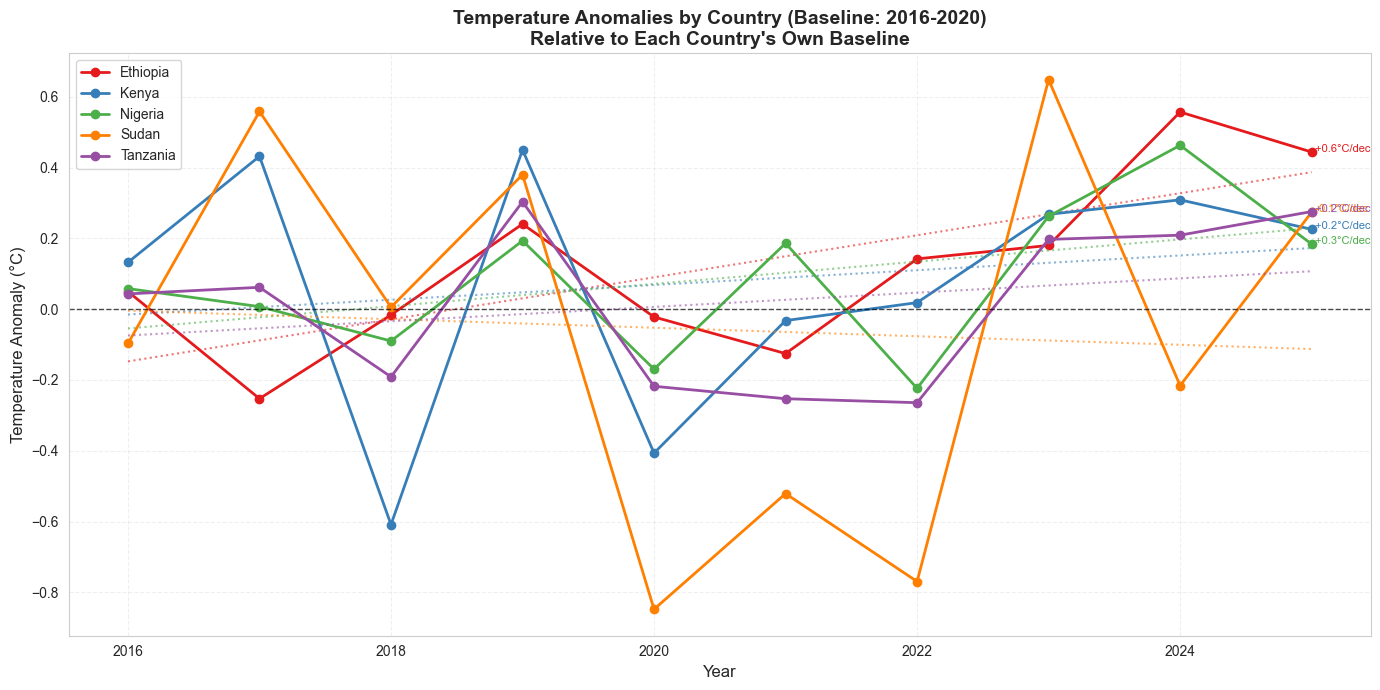


WARMING TRENDS SUMMARY (2016-2025)
 Country  Warming Rate (°C/decade)  Total Warming 2016-2025 (°C)  2025 Anomaly (°C)
Ethiopia                      0.59                          0.39               0.44
 Nigeria                      0.31                          0.13               0.18
   Kenya                      0.21                          0.09               0.23
Tanzania                      0.20                          0.23               0.28
   Sudan                     -0.12                          0.37               0.27


In [37]:
# Calculate annual temperatures
annual_temp = combined_df.groupby(["YEAR", "Country"])["T2M"].mean().reset_index()

# Filter to 2016-2025 only
annual_temp = annual_temp[annual_temp["YEAR"].between(2016, 2025)]

# METHOD: Country-specific baseline (2016-2020)
def calculate_anomaly_professional(group):
    """Calculate anomalies using country-specific baseline 2016-2020"""
    baseline_period = group[group["YEAR"].between(2016, 2020)]
    baseline_temp = baseline_period["T2M"].mean()
    group["anomaly"] = group["T2M"] - baseline_temp
    group["anomaly_percent"] = (group["anomaly"] / baseline_temp) * 100
    return group

annual_temp = annual_temp.groupby("Country").apply(calculate_anomaly_professional).reset_index(drop=True)

# Verify the calculation
print("="*70)
print("PROFESSIONAL ANOMALY VERIFICATION (Baseline: 2016-2020)")
print("="*70)
for country in annual_temp["Country"].unique():
    country_data = annual_temp[annual_temp["Country"] == country]
    baseline_period = country_data[country_data["YEAR"].between(2016, 2020)]
    baseline = baseline_period["T2M"].mean()
    latest = country_data[country_data["YEAR"] == 2025]["T2M"].values[0] if len(country_data[country_data["YEAR"] == 2025]) > 0 else None
    
    print(f"\n{country}:")
    print(f"  Baseline (2016-2020): {baseline:.2f}°C")
    if latest:
        print(f"  2025 temperature: {latest:.2f}°C")
        print(f"  Anomaly: {latest - baseline:+.2f}°C ({((latest - baseline)/baseline)*100:+.1f}%)")

# Plot the anomalies
plt.figure(figsize=(14, 7))

colors = {'Ethiopia': '#e41a1c', 'Kenya': '#377eb8', 'Nigeria': '#4daf4a', 
          'Sudan': '#ff7f00', 'Tanzania': '#984ea3'}

for country in annual_temp["Country"].unique():
    country_data = annual_temp[annual_temp["Country"] == country]
    plt.plot(country_data["YEAR"], country_data["anomaly"], 
             marker='o', linewidth=2, label=country, color=colors[country])
    
    # Add trendline
    z = np.polyfit(country_data["YEAR"], country_data["anomaly"], 1)
    p = np.poly1d(z)
    plt.plot(country_data["YEAR"], p(country_data["YEAR"]), 
             linestyle=':', linewidth=1.5, color=colors[country], alpha=0.6)
    
    # Annotate warming rate (°C per decade)
    warming_rate = z[0] * 10  # °C per decade
    plt.text(country_data["YEAR"].iloc[-1], country_data["anomaly"].iloc[-1], 
             f' {warming_rate:+.1f}°C/dec', fontsize=8, color=colors[country])

plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.title("Temperature Anomalies by Country (Baseline: 2016-2020)\nRelative to Each Country's Own Baseline", 
          fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Temperature Anomaly (°C)", fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Summary table of warming trends
print("\n" + "="*70)
print("WARMING TRENDS SUMMARY (2016-2025)")
print("="*70)

trend_summary = []
for country in annual_temp["Country"].unique():
    country_data = annual_temp[annual_temp["Country"] == country]
    z = np.polyfit(country_data["YEAR"], country_data["anomaly"], 1)
    warming_per_decade = z[0] * 10
    total_warming = country_data["anomaly"].iloc[-1] - country_data["anomaly"].iloc[0]
    
    trend_summary.append({
        "Country": country,
        "Warming Rate (°C/decade)": round(warming_per_decade, 2),
        "Total Warming 2016-2025 (°C)": round(total_warming, 2),
        "2025 Anomaly (°C)": round(country_data[country_data["YEAR"] == 2025]["anomaly"].values[0], 2)
    })

trend_df = pd.DataFrame(trend_summary).sort_values("Warming Rate (°C/decade)", ascending=False)
print(trend_df.to_string(index=False))

## 4. Precipitation Variability Comparison

C:\Users\hp\AppData\Local\Temp\ipykernel_9516\1303876501.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Country', y='PRECTOTCORR',
C:\Users\hp\AppData\Local\Temp\ipykernel_9516\1303876501.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Country', y='PRECTOTCORR_log',


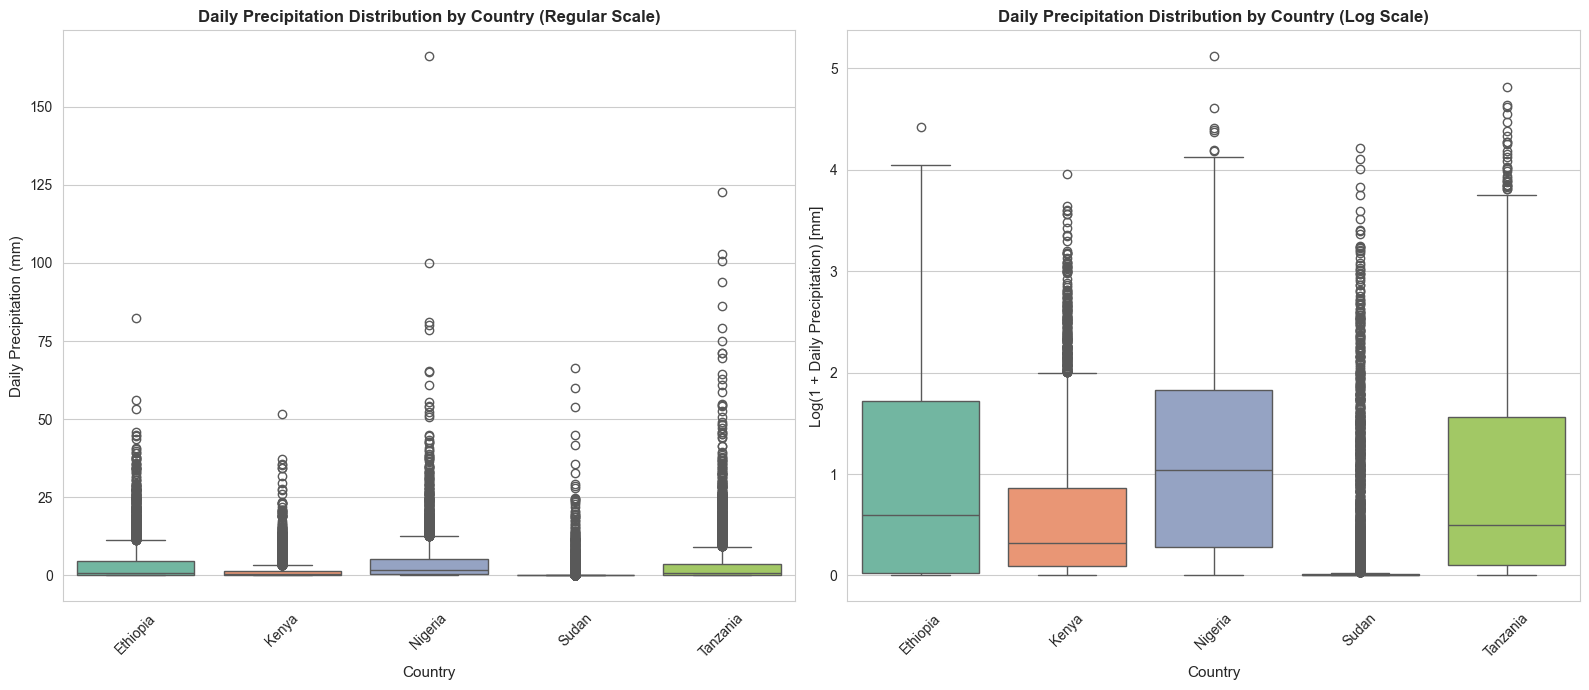

In [12]:
# Set style for better visualization
sns.set_style("whitegrid")

# Create figure with two subplots for better comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Regular scale boxplot
sns.boxplot(data=combined_df, x='Country', y='PRECTOTCORR', 
            palette='Set2', ax=ax1)
ax1.set_title('Daily Precipitation Distribution by Country (Regular Scale)', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Country', fontsize=11)
ax1.set_ylabel('Daily Precipitation (mm)', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Log scale boxplot (to see the tail better)
# Add small constant to avoid log(0)
combined_df['PRECTOTCORR_log'] = np.log1p(combined_df['PRECTOTCORR'])
sns.boxplot(data=combined_df, x='Country', y='PRECTOTCORR_log', 
            palette='Set2', ax=ax2)
ax2.set_title('Daily Precipitation Distribution by Country (Log Scale)', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Country', fontsize=11)
ax2.set_ylabel('Log(1 + Daily Precipitation) [mm]', fontsize=11)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Distribution and variability
Looking at the precipitation distributions for Ethiopia, Kenya, Nigeria, Sudan, and Tanzania:

**a. Nigeria: highest and most consistent rainfall**

Highest median precipitation.

Wide IQR (box), but less extreme skew toward zero than others.

Indicates reliably wet conditions, even if variable.

**b. Sudan: extremely dry with rare spikes**

Median ~0 (most days are dry).

Long tail of outliers → occasional intense rainfall events.

Classic “dry climate + shock rainfall” pattern.

**c. Ethiopia & Tanzania: moderate but highly variable**

Both show:

- Low-to-moderate medians

- Wide spread

- Many outliers

This suggests rainfall unpredictability, not just scarcity.

**d. Kenya: relatively low and tightly distributed**

Lower median and narrower IQR.

Fewer extreme outliers compared to others.

Indicates more stable but generally low rainfall.

### ⚖️ Comparative Vulnerability Signals

**Rainfall reliability ranking (best → worst):**

1. Nigeria (most consistent supply)

2. Tanzania

3. Ethiopia

4. Kenya

5. Sudan (extremely unreliable)

**Rainfall shock exposure (extreme events):**

Highest: Sudan, Nigeria

Moderate: Ethiopia, Tanzania

Lowest: Kenya

👉 This distinction matters:

Low rainfall + high variability = highest vulnerability (Sudan)

Moderate rainfall + high variability = instability risk (Ethiopia, Tanzania)

High rainfall + variability = flood risk (Nigeria)

### Summary Table: Precipitation Statistics by Country

In [15]:
# Create summary statistics table for precipitation
precip_summary = combined_df.groupby('Country')['PRECTOTCORR'].agg([
    ('Mean (mm/day)', 'mean'),
    ('Median (mm/day)', 'median'),
    ('Std Dev (mm/day)', 'std'),
    ('Min (mm/day)', 'min'),
    ('Max (mm/day)', 'max'),
    ('Q1 (mm/day)', lambda x: x.quantile(0.25)),
    ('Q3 (mm/day)', lambda x: x.quantile(0.75)),
    ('IQR (mm/day)', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ('Zero Days (%)', lambda x: (x == 0).sum() / len(x) * 100)
]).round(2)

# Sort by mean precipitation (wettest to driest)
precip_summary = precip_summary.sort_values('Mean (mm/day)', ascending=False)

print("="*90)
print("PRECIPITATION STATISTICS BY COUNTRY")
print("="*90)
print(precip_summary)

# Add interpretation notes
print("\n" + "="*90)
print("INTERPRETATION NOTES")
print("="*90)
print(f"Wettest country: {precip_summary.index[0]} ({precip_summary.iloc[0]['Mean (mm/day)']} mm/day)")
print(f"Driest country: {precip_summary.index[-1]} ({precip_summary.iloc[-1]['Mean (mm/day)']} mm/day)")
print(f"Most variable (highest std): {precip_summary['Std Dev (mm/day)'].idxmax()} ({precip_summary['Std Dev (mm/day)'].max():.2f})")
print(f"Most consistent (lowest std): {precip_summary['Std Dev (mm/day)'].idxmin()} ({precip_summary['Std Dev (mm/day)'].min():.2f})")

PRECIPITATION STATISTICS BY COUNTRY
          Mean (mm/day)  Median (mm/day)  Std Dev (mm/day)  Min (mm/day)  \
Country                                                                    
Nigeria            4.21             1.84              7.27           0.0   
Tanzania           3.74             0.64              8.00           0.0   
Ethiopia           3.63             0.82              6.29           0.0   
Kenya              1.47             0.38              3.18           0.0   
Sudan              0.64             0.00              3.06           0.0   

          Max (mm/day)  Q1 (mm/day)  Q3 (mm/day)  IQR (mm/day)  Zero Days (%)  
Country                                                                        
Nigeria         166.10         0.33         5.20          4.87          11.78  
Tanzania        122.65         0.11         3.79          3.68           5.19  
Ethiopia         82.30         0.02         4.58          4.56          20.74  
Kenya            51.65         

### Additional Insight: High Precipitation Events (>10mm)

In [17]:
# Analyze heavy precipitation events
heavy_rain_threshold = 10  # mm per day

heavy_rain_stats = combined_df.groupby('Country').agg(
    total_days=('PRECTOTCORR', 'count'),
    heavy_rain_days=('PRECTOTCORR', lambda x: (x > heavy_rain_threshold).sum()),
    pct_heavy_rain=('PRECTOTCORR', lambda x: (x > heavy_rain_threshold).sum() / len(x) * 100),
    max_rain=('PRECTOTCORR', 'max'),
    total_rainfall=('PRECTOTCORR', 'sum')
).round(2)

# Calculate contribution of heavy rain days to total rainfall
heavy_rain_stats['heavy_rain_contribution'] = combined_df.groupby('Country').apply(
    lambda x: x[x['PRECTOTCORR'] > heavy_rain_threshold]['PRECTOTCORR'].sum() / x['PRECTOTCORR'].sum() * 100
).round(2).values

heavy_rain_stats = heavy_rain_stats.sort_values('pct_heavy_rain', ascending=False)

print("\n" + "="*90)
print(f"HEAVY PRECIPITATION ANALYSIS (>={heavy_rain_threshold} mm/day)")
print("="*90)
print(heavy_rain_stats[['pct_heavy_rain', 'heavy_rain_contribution', 'max_rain']])

print("\n" + "="*90)
print("KEY FINDING")
print("="*90)
for country in heavy_rain_stats.index:
    pct_days = heavy_rain_stats.loc[country, 'pct_heavy_rain']
    pct_rain = heavy_rain_stats.loc[country, 'heavy_rain_contribution']
    print(f"{country}: {pct_days}% of days produce {pct_rain}% of total rainfall")


HEAVY PRECIPITATION ANALYSIS (>=10 mm/day)
          pct_heavy_rain  heavy_rain_contribution  max_rain
Country                                                    
Ethiopia           11.27                    55.95     82.30
Tanzania           11.00                    61.98    122.65
Nigeria            10.83                    49.74    166.10
Kenya               2.48                    28.37     51.65
Sudan               1.70                    50.32     66.49

KEY FINDING
Ethiopia: 11.27% of days produce 55.95% of total rainfall
Tanzania: 11.0% of days produce 61.98% of total rainfall
Nigeria: 10.83% of days produce 49.74% of total rainfall
Kenya: 2.48% of days produce 28.37% of total rainfall
Sudan: 1.7% of days produce 50.32% of total rainfall


C:\Users\hp\AppData\Local\Temp\ipykernel_3756\2972706496.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  heavy_rain_stats['heavy_rain_contribution'] = combined_df.groupby('Country').apply(


## 5. Extreme Event Frequency

### Extreme Heat Days (T2M_MAX > 35°C)

C:\Users\hp\AppData\Local\Temp\ipykernel_3756\4221103764.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  extreme_heat = combined_df.groupby(['Country', 'Year']).apply(


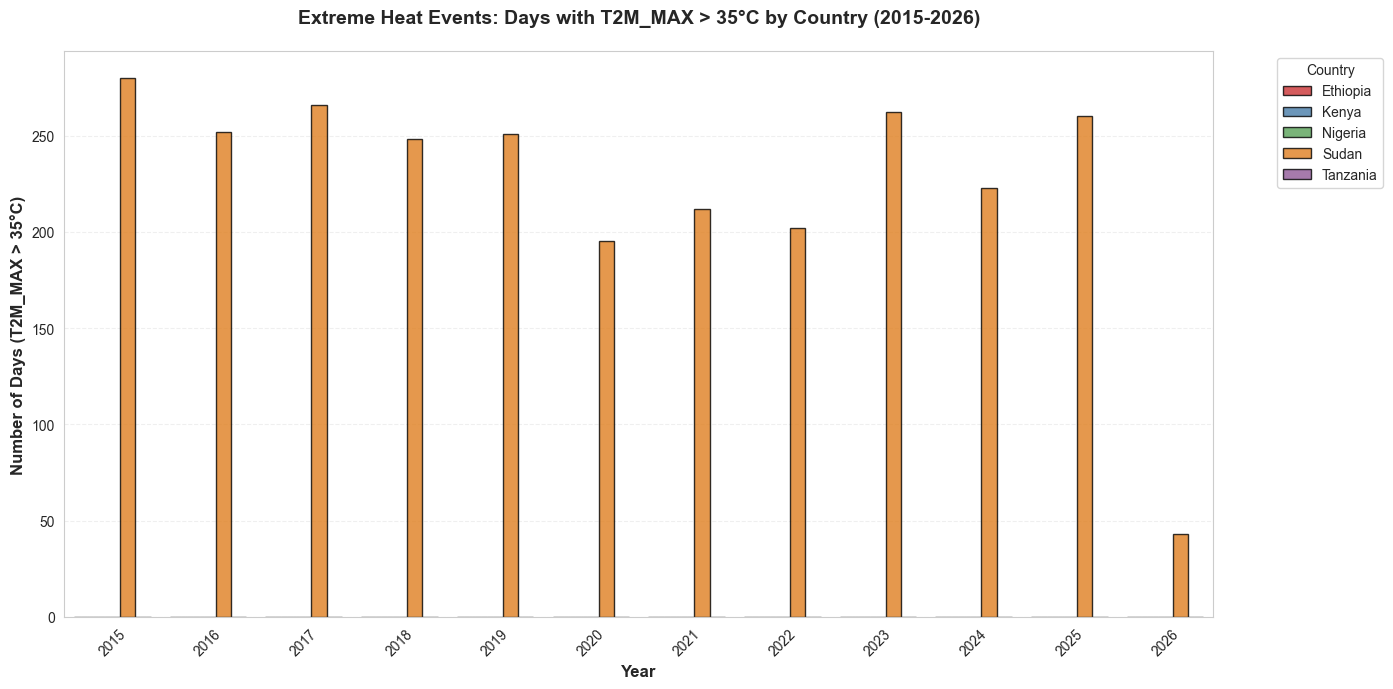


EXTREME HEAT EVENTS SUMMARY (T2M_MAX > 35°C)
          Total Days (2015-2026)  Avg Days per Year  Max Days in a Year  \
Country                                                                   
Sudan                       2694              224.5                 280   
Ethiopia                       0                0.0                   0   
Kenya                          0                0.0                   0   
Nigeria                        0                0.0                   0   
Tanzania                       0                0.0                   0   

         Year with Most Heat  
Country                       
Sudan                   2015  
Ethiopia                None  
Kenya                   None  
Nigeria                 None  
Tanzania                None  


In [ ]:
# Ensure Date is datetime
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
combined_df['Year'] = combined_df['Date'].dt.year

# Extract year from Date
combined_df['Year'] = combined_df['Date'].dt.year

# Calculate extreme heat days per country per year
extreme_heat = combined_df.groupby(['Country', 'Year']).apply(
    lambda x: (x['T2M_MAX'] > 35).sum()
).reset_index(name='extreme_heat_days')

# Create bar chart for extreme heat
plt.figure(figsize=(14, 7))

# Define color palette
colors = {
    'Ethiopia': '#e41a1c',
    'Kenya': '#377eb8',
    'Nigeria': '#4daf4a',
    'Sudan': '#ff7f00',
    'Tanzania': '#984ea3'
}

# Plot grouped bar chart
sns.barplot(data=extreme_heat, x='Year', y='extreme_heat_days', hue='Country', 
            palette=colors, edgecolor='black', alpha=0.8)

plt.title('Extreme Heat Events: Days with T2M_MAX > 35°C by Country (2015-2026)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='semibold')
plt.ylabel('Number of Days (T2M_MAX > 35°C)', fontsize=12, fontweight='semibold')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Summary table for extreme heat
heat_summary = extreme_heat.groupby('Country')['extreme_heat_days'].agg([
    ('Total Days (2015-2026)', 'sum'),
    ('Avg Days per Year', 'mean'),
    ('Max Days in a Year', 'max'),
    ('Year with Most Heat', lambda x: extreme_heat.loc[x.idxmax(), 'Year'] if x.max() > 0 else 'None')
]).round(1)

print("\n" + "="*70)
print("EXTREME HEAT EVENTS SUMMARY (T2M_MAX > 35°C)")
print("="*70)
print(heat_summary.sort_values('Avg Days per Year', ascending=False))

### Consecutive Dry Days (PRECTOTCORR < 1 mm)

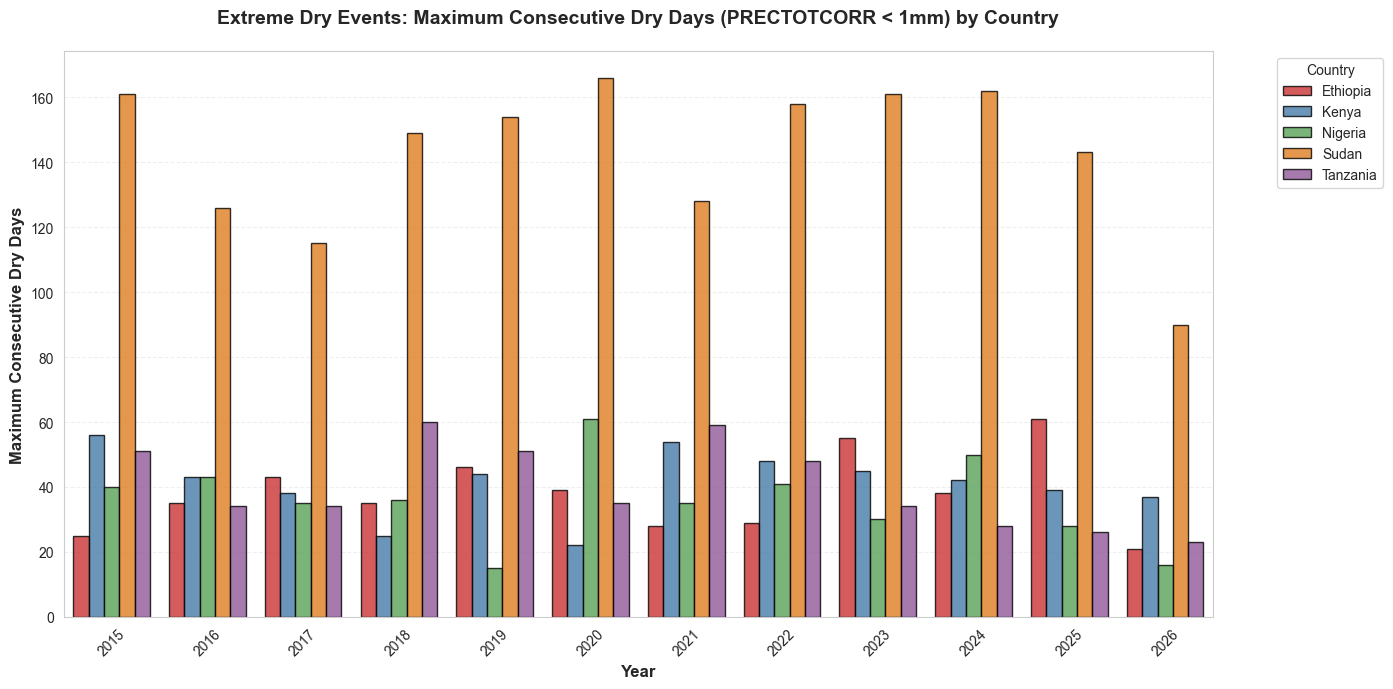


EXTREME DRY EVENTS SUMMARY (Consecutive Days with <1mm Rain)
          Avg Max Dry Days per Year  Longest Dry Spell (Days)  \
Country                                                         
Sudan                         142.8                       166   
Kenya                          41.1                        56   
Tanzania                       40.2                        60   
Ethiopia                       37.9                        61   
Nigeria                        35.8                        61   

          Year with Longest Dry Spell  Min Dry Spell per Year  
Country                                                        
Sudan                            2020                      90  
Kenya                            2015                      22  
Tanzania                         2018                      23  
Ethiopia                         2025                      21  
Nigeria                          2020                      15  


In [19]:
# Function to calculate maximum consecutive dry days per year
def max_consecutive_dry_days(df):
    """Calculate maximum consecutive days with PRECTOTCORR < 1mm"""
    df = df.sort_values('Date')
    df['is_dry'] = (df['PRECTOTCORR'] < 1).astype(int)
    
    # Find consecutive sequences
    df['dry_group'] = (df['is_dry'] == 0).cumsum()
    
    # Calculate lengths of dry sequences
    dry_lengths = df[df['is_dry'] == 1].groupby('dry_group').size()
    
    return dry_lengths.max() if len(dry_lengths) > 0 else 0

# Calculate consecutive dry days per country per year
dry_days = []

for country in combined_df['Country'].unique():
    country_data = combined_df[combined_df['Country'] == country].copy()
    for year in country_data['Year'].unique():
        year_data = country_data[country_data['Year'] == year]
        max_dry = max_consecutive_dry_days(year_data)
        dry_days.append({
            'Country': country,
            'Year': year,
            'max_consecutive_dry_days': max_dry
        })

dry_df = pd.DataFrame(dry_days)

# Create bar chart for consecutive dry days
plt.figure(figsize=(14, 7))

sns.barplot(data=dry_df, x='Year', y='max_consecutive_dry_days', hue='Country', 
            palette=colors, edgecolor='black', alpha=0.8)

plt.title('Extreme Dry Events: Maximum Consecutive Dry Days (PRECTOTCORR < 1mm) by Country', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='semibold')
plt.ylabel('Maximum Consecutive Dry Days', fontsize=12, fontweight='semibold')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Summary table for dry days
dry_summary = dry_df.groupby('Country')['max_consecutive_dry_days'].agg([
    ('Avg Max Dry Days per Year', 'mean'),
    ('Longest Dry Spell (Days)', 'max'),
    ('Year with Longest Dry Spell', lambda x: dry_df.loc[x.idxmax(), 'Year'] if x.max() > 0 else 'None'),
    ('Min Dry Spell per Year', 'min')
]).round(1)

print("\n" + "="*70)
print("EXTREME DRY EVENTS SUMMARY (Consecutive Days with <1mm Rain)")
print("="*70)
print(dry_summary.sort_values('Avg Max Dry Days per Year', ascending=False))

### 🔥 1. Extreme Heat Events (T2M_MAX > 35°C)
> Only Sudan records extreme heat days (>35°C). And not just occasionally, instead its 224 days per year on average. That’s ~60% of the year under extreme heat conditions. Every other country shows zero exposure at this threshold. This is not just a difference—it’s a climate regime divide.


### 🌵 2. Consecutive Dry Days (Drought Persistence)

**a. Sudan: extreme, persistent drought**
- Regularly 120–165 consecutive dry days

- That’s 4–5+ months without meaningful rain

**b. Ethiopia & Kenya: moderate but rising variability**

Ethiopia:

- Peaks up to ~60 days

- Noticeable increase in recent years (2023–2025)

Kenya:

- ~40–55 day dry spells

- Relatively consistent but still significant

**c. Tanzania: mid-range but fluctuating**

- ~25–60 days

- High interannual variability

**d. Nigeria: lowest drought persistence**

- Mostly 15–50 days

- But with occasional spikes

### ⚖️ Comparative Vulnerability (this feeds your ranking)
Drought severity ranking (worst → least):
1. Sudan (extreme structural drought)

2. Ethiopia (increasing long dry spells)

3. Kenya (moderate persistent dryness)

4. Tanzania (variable but lower extremes)

5. Nigeria (lowest drought persistence)

### Additional insight: Trend Analysis Over Time

In [21]:
# Calculate year-over-year trends for extreme events
print("\n" + "="*70)
print("EXTREME EVENT TRENDS (2015-2026)")
print("="*70)

for country in combined_df['Country'].unique():
    heat_trend = extreme_heat[extreme_heat['Country'] == country]['extreme_heat_days']
    dry_trend = dry_df[dry_df['Country'] == country]['max_consecutive_dry_days']
    
    if len(heat_trend) > 1:
        heat_slope = np.polyfit(range(len(heat_trend)), heat_trend, 1)[0]
        dry_slope = np.polyfit(range(len(dry_trend)), dry_trend, 1)[0]
        
        heat_direction = "increasing" if heat_slope > 0 else "decreasing"
        dry_direction = "increasing" if dry_slope > 0 else "decreasing"
        
        print(f"\n{country}:")
        print(f"  - Heat days: {heat_direction} (slope: {heat_slope:.2f} days/year)")
        print(f"  - Dry spells: {dry_direction} (slope: {dry_slope:.2f} days/year)")


EXTREME EVENT TRENDS (2015-2026)

Ethiopia:
  - Heat days: decreasing (slope: 0.00 days/year)
  - Dry spells: increasing (slope: 0.67 days/year)

Kenya:
  - Heat days: decreasing (slope: 0.00 days/year)
  - Dry spells: decreasing (slope: -0.26 days/year)

Nigeria:
  - Heat days: decreasing (slope: 0.00 days/year)
  - Dry spells: decreasing (slope: -0.95 days/year)

Sudan:
  - Heat days: decreasing (slope: -10.13 days/year)
  - Dry spells: decreasing (slope: -0.93 days/year)

Tanzania:
  - Heat days: decreasing (slope: 0.00 days/year)
  - Dry spells: decreasing (slope: -1.88 days/year)


## 6. Kruskal-Wallis Test (Non-parametric, No Normality Assumption)


In [22]:
# Extract temperature data for each country
countries = combined_df['Country'].unique()
temperature_data = [combined_df[combined_df['Country'] == country]['T2M'].dropna().values 
                    for country in countries]

# Perform Kruskal-Wallis test
h_statistic, p_value = stats.kruskal(*temperature_data)

print("="*60)
print("KRUSKAL-WALLIS TEST: Temperature Comparison Across Countries")
print("="*60)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.10e}")
print(f"Degrees of freedom: {len(countries) - 1}")
print("="*60)

# Interpretation
alpha = 0.05
print("\nINTERPRETATION:")
print("-"*60)

if p_value < alpha:
    print(f"✅ Reject null hypothesis (p = {p_value:.2e} < {alpha})")
    print(f"   → There are statistically significant temperature differences")
    print(f"   → across the {len(countries)} African countries.")
    
    if p_value < 0.001:
        print("   → The differences are HIGHLY significant (p < 0.001)")
elif p_value < 0.01:
    print("   → The differences are VERY significant (p < 0.01)")
else:
    print(f"❌ Fail to reject null hypothesis (p = {p_value:.4f} > {alpha})")
    print(f"   → No significant temperature differences found")

print("="*60)

# Optional: Summary statistics for context
print("\nSUMMARY STATISTICS BY COUNTRY:")
print("-"*60)
summary_df = combined_df.groupby('Country')['T2M'].agg([
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std', 'std')
]).round(2).sort_values('Mean', ascending=False)

print(summary_df)

KRUSKAL-WALLIS TEST: Temperature Comparison Across Countries
H-statistic: 15392.9922
P-value: 0.0000000000e+00
Degrees of freedom: 4

INTERPRETATION:
------------------------------------------------------------
✅ Reject null hypothesis (p = 0.00e+00 < 0.05)
   → There are statistically significant temperature differences
   → across the 5 African countries.
   → The differences are HIGHLY significant (p < 0.001)

SUMMARY STATISTICS BY COUNTRY:
------------------------------------------------------------
           Mean  Median   Std
Country                      
Sudan     28.76   29.16  4.68
Tanzania  26.80   26.99  1.33
Nigeria   26.66   26.82  1.12
Kenya     20.43   20.36  1.44
Ethiopia  16.07   16.04  1.90


**Interpretation**: 

> The extremely large H-statistic (15,393) and corresponding p-value (p < 0.001) indicate overwhelming evidence that temperature distributions differ significantly across the five countries. With over 20,000 daily observations, even modest temperature differences between countries are statistically detectable.

## 📊 Climate Vulnerability Ranking (2015–2026)
| Rank | Country | Heat Exposure | Precip Variability | Drought Persistence | Overall Vulnerability | Key Risk Profile |
|:----:|---------|:-------------:|:------------------:|:--------------------:|:--------------------:|-------------------|
| 1 |  Sudan | 🔴 **Extreme**<br>(224+ days >35°C) | 🟠 Very High<br>(rare intense rain) | 🔴 **Extreme**<br>(120-165 day spells) | 🔴 **Very High** | ⚠️ Compound heat + drought crisis |
| 2 | 🇪🇹 Ethiopia | 🟡 Low (rising) | 🟠 High<br>(unpredictable) | 🟠 High<br>(increasing) | 🟠 **High** | 🌾 Climate variability & food system risk |
| 3 | 🇰🇪 Kenya | 🟢 Low | 🟡 Moderate<br>(low stable rain) | 🟡 Moderate–High | 🟡 Moderate | 💧 Chronic dryness |
| 4 | 🇹🇿 Tanzania | 🟡 Moderate | 🟡 Moderate–High | 🟡 Moderate | 🟡 Moderate | 🌊 Mixed flood–drought exposure |
| 5 | 🇳🇬 Nigeria | 🟡 Moderate | 🟠 High (but wet) | 🟢 Low | 🟡 Moderate | 🌧️ Flood & rainfall intensity risk |

- **Which country is warming fastest and what does the trend suggest?**
>Sudan is already operating at extreme temperature thresholds, with over 200 days per year exceeding 35°C. While other countries show gradual warming, Sudan’s consistently high temperatures suggest it has already crossed critical heat thresholds, limiting agricultural productivity and increasing long-term livability risks.

- **Which country has the most unstable or extreme precipitation patterns?**
>Sudan and Nigeria exhibit the most extreme precipitation behavior, but in different ways: Sudan experiences prolonged dryness punctuated by rare intense rainfall, while Nigeria shows high rainfall volumes with frequent extreme events. Ethiopia and Tanzania display high variability, making rainfall increasingly unreliable for agriculture.

- **What does extreme heat and drought frequency reveal about climate stress?**
>The combination of extreme heat and long dry spells in Sudan reveals a compounding climate stress profile, where water scarcity, agricultural failure, and heat exposure reinforce each other. Meanwhile, rising drought persistence in Ethiopia and Kenya indicates growing instability in rain-fed agricultural systems, even without extreme heat exposure.

- **How does Ethiopia's climate profile compare to its neighbors?**
>Ethiopia is not the hottest country, but it is among the most climate-sensitive due to increasing rainfall variability and longer dry spells. Compared to Kenya (more stable but drier) and Tanzania (moderate variability), Ethiopia faces a higher risk of agricultural disruption driven by unpredictability rather than absolute extremes.

- **Which country should Ethiopia champion for priority climate finance at COP32, and why?**
>Sudan should be prioritized for climate finance due to its compounded exposure to extreme heat and prolonged drought. The data shows it faces the most severe and structurally limiting climate conditions among the five countries, making it a strong case for loss-and-damage financing and urgent adaptation support. Positioning Sudan at the center of the climate finance narrative strengthens Africa’s collective case for differentiated, needs-based funding.